# 01 — EDA for Customer-Churn-Records

**Source:** `archive/Customer-Churn-Records.csv`  
**Target:** `Exited` (`1` = churn, `0` = retained)

Notebook này mô tả schema, data quality, phân phối và mức độ phân hóa của từng feature đối với churn. Đây là EDA trên training data; chưa thực hiện train/validation model.

## Nguyên tắc phân tích

- `RowNumber`, `CustomerId` và `Surname` được audit nhưng loại khỏi candidate feature vì là định danh hoặc text có cardinality cao.
- `Exited` chỉ được dùng làm target cho EDA có giám sát.
- `Complain` chỉ được giữ ở phần audit để phát hiện leakage; correlation, bảng xếp hạng chính và top-feature profiles tạm thời loại cột này.
- Thước đo Jensen–Shannon (JS) divergence trong notebook là thống kê đơn biến mô tả training data, không thay thế validation.

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42
TARGET = 'Exited'
IDENTIFIER_COLUMNS = ['RowNumber', 'CustomerId', 'Surname']

In [3]:
DATA_PATH = Path('archive/Customer-Churn-Records.csv')
df = pd.read_csv(DATA_PATH)

assert TARGET in df.columns, f'Missing target: {TARGET}'
assert all(column in df.columns for column in IDENTIFIER_COLUMNS)

feature_columns = [
    column for column in df.columns
    if column not in IDENTIFIER_COLUMNS + [TARGET]
]
model_feature_columns = [
    column for column in feature_columns if column != 'Complain'
]

print(f'File: {DATA_PATH}')
print(f'Shape: {df.shape}')
print(f'Non-ID features audited: {len(feature_columns)}')
print(f'Model candidates with Complain temporarily excluded: {len(model_feature_columns)}')
print(f'Identifier columns excluded: {IDENTIFIER_COLUMNS}')

File: archive/Customer-Churn-Records.csv
Shape: (10000, 18)
Non-ID features audited: 14
Model candidates with Complain temporarily excluded: 13
Identifier columns excluded: ['RowNumber', 'CustomerId', 'Surname']


# 1. Tổng quan dataset và target

In [4]:
target_counts = df[TARGET].value_counts().sort_index()
overview = pd.DataFrame({
    'Metric': [
        'Rows', 'Columns', 'Model candidates (no Complain)', 'Missing cells',
        'Duplicate rows', 'Retained rows', 'Churn rows', 'Churn rate',
    ],
    'Value': [
        len(df), df.shape[1], len(model_feature_columns), int(df.isna().sum().sum()),
        int(df.duplicated().sum()), int(target_counts.get(0, 0)),
        int(target_counts.get(1, 0)), f'{df[TARGET].mean():.2%}',
    ],
})
display(overview)
display(df.head(3))

,Metric,Value
0,Rows,10000
1,Columns,18
2,Model candidates (no Complain),13
3,Missing cells,0
4,Duplicate rows,0
5,Retained rows,7962
6,Churn rows,2038
7,Churn rate,20.38%


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.0000,1,1,1,"101,348.8800",1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,"83,807.8600",1,0,1,"112,542.5800",0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,"159,660.8000",3,1,0,"113,931.5700",1,1,3,DIAMOND,377


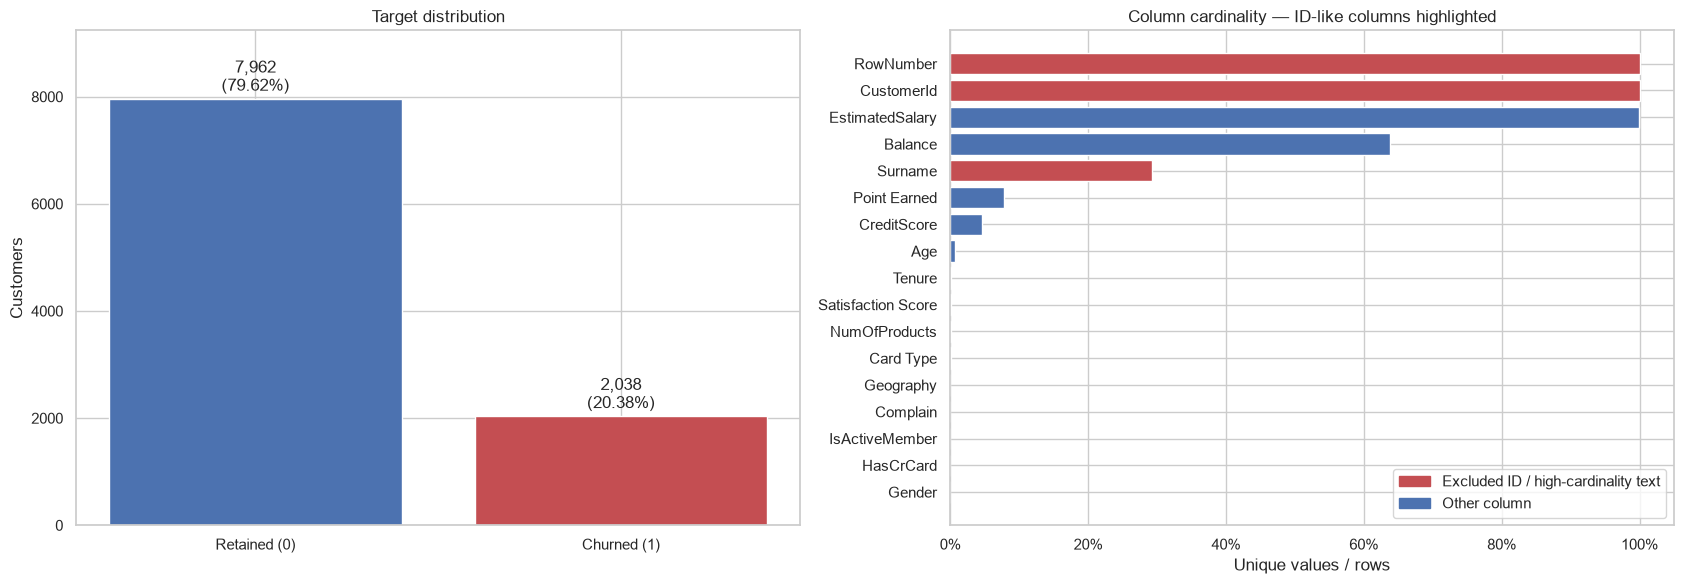

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

target_plot = (
    df[TARGET].value_counts().sort_index()
    .rename(index={0: 'Retained (0)', 1: 'Churned (1)'})
)
bars = axes[0].bar(
    target_plot.index,
    target_plot.values,
    color=['#4C72B0', '#C44E52'],
)
for bar, count in zip(bars, target_plot.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + len(df) * 0.015,
        f'{count:,}\n({count / len(df):.2%})',
        ha='center',
    )
axes[0].set_ylim(0, target_plot.max() * 1.16)
axes[0].set_ylabel('Customers')
axes[0].set_title('Target distribution')

cardinality = pd.DataFrame({
    'Column': [column for column in df.columns if column != TARGET],
    'Unique rate': [
        df[column].nunique(dropna=False) / len(df)
        for column in df.columns if column != TARGET
    ],
})
cardinality = cardinality.sort_values('Unique rate', ascending=True)
colors = [
    '#C44E52' if column in IDENTIFIER_COLUMNS else '#4C72B0'
    for column in cardinality['Column']
]
axes[1].barh(cardinality['Column'], cardinality['Unique rate'], color=colors)
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_xlabel('Unique values / rows')
axes[1].set_title('Column cardinality — ID-like columns highlighted')
axes[1].legend(
    handles=[
        Patch(color='#C44E52', label='Excluded ID / high-cardinality text'),
        Patch(color='#4C72B0', label='Other column'),
    ],
    loc='lower right',
)

fig.tight_layout()
plt.show()

# 2. Column profile: name, type, missing rate và 3 examples

`Example data` lấy đúng ba quan sát đầu tiên không-null của mỗi cột; giá trị có thể lặp vì đây là example theo dòng, không phải danh sách unique.

In [6]:
ROLE_MAP = {
    'RowNumber': 'Row index — exclude',
    'CustomerId': 'Customer identifier — exclude',
    'Surname': 'High-cardinality text — exclude',
    'Exited': 'Binary target',
    'Geography': 'Nominal categorical',
    'Gender': 'Nominal categorical',
    'Card Type': 'Nominal categorical',
    'HasCrCard': 'Binary categorical',
    'IsActiveMember': 'Binary categorical',
    'Complain': 'Binary categorical — leakage risk',
    'Satisfaction Score': 'Ordinal categorical',
    'NumOfProducts': 'Discrete numeric',
    'Tenure': 'Discrete numeric',
}


def infer_semantic_role(column):
    if column in ROLE_MAP:
        return ROLE_MAP[column]
    if pd.api.types.is_numeric_dtype(df[column]):
        return 'Numeric'
    return 'Categorical'


def three_examples(series):
    examples = series.dropna().head(3).tolist()
    return repr(examples)


column_profile = pd.DataFrame({
    'Name': df.columns,
    'Type': [str(df[column].dtype) for column in df.columns],
    'Semantic role': [infer_semantic_role(column) for column in df.columns],
    'Missing Count': [int(df[column].isna().sum()) for column in df.columns],
    'Missing Rate': [float(df[column].isna().mean()) for column in df.columns],
    'Unique Values': [int(df[column].nunique(dropna=True)) for column in df.columns],
    'Example data (3 rows)': [three_examples(df[column]) for column in df.columns],
})

column_profile.style.format({
    'Missing Rate': '{:.2%}',
    'Missing Count': '{:,}',
    'Unique Values': '{:,}',
}).set_properties(subset=['Example data (3 rows)'], **{'text-align': 'left'})

,Name,Type,Semantic role,Missing Count,Missing Rate,Unique Values,Example data (3 rows)
0,RowNumber,int64,Row index — exclude,0,0.00%,"10,000","[1, 2, 3]"
1,CustomerId,int64,Customer identifier — exclude,0,0.00%,"10,000","[15634602, 15647311, 15619304]"
2,Surname,object,High-cardinality text — exclude,0,0.00%,"2,932","['Hargrave', 'Hill', 'Onio']"
3,CreditScore,int64,Numeric,0,0.00%,460,"[619, 608, 502]"
4,Geography,object,Nominal categorical,0,0.00%,3,"['France', 'Spain', 'France']"
5,Gender,object,Nominal categorical,0,0.00%,2,"['Female', 'Female', 'Female']"
6,Age,int64,Numeric,0,0.00%,70,"[42, 41, 42]"
7,Tenure,int64,Discrete numeric,0,0.00%,11,"[2, 1, 8]"
8,Balance,float64,Numeric,0,0.00%,"6,382","[0.0, 83807.86, 159660.8]"
9,NumOfProducts,int64,Discrete numeric,0,0.00%,4,"[1, 1, 3]"


In [7]:
id_audit = pd.DataFrame({
    'Column': IDENTIFIER_COLUMNS,
    'Unique values': [df[column].nunique(dropna=False) for column in IDENTIFIER_COLUMNS],
    'Unique rate': [df[column].nunique(dropna=False) / len(df) for column in IDENTIFIER_COLUMNS],
    'Duplicate values': [int(df[column].duplicated().sum()) for column in IDENTIFIER_COLUMNS],
    'Model action': ['Exclude', 'Exclude', 'Exclude'],
})

complain_exit_crosstab = pd.crosstab(
    df['Complain'], df[TARGET], margins=True
)
complain_churn_rate = (
    df.groupby('Complain', observed=True)[TARGET]
    .agg(['mean', 'size'])
    .rename(columns={'mean': 'Churn rate', 'size': 'Customers'})
)

display(id_audit.style.format({'Unique rate': '{:.2%}'}))
display(Markdown('### `Complain` vs `Exited` — leakage-risk audit'))
display(complain_exit_crosstab)
display(complain_churn_rate.style.format({'Churn rate': '{:.2%}', 'Customers': '{:,}'}))

,Column,Unique values,Unique rate,Duplicate values,Model action
0,RowNumber,10000,100.00%,0,Exclude
1,CustomerId,10000,100.00%,0,Exclude
2,Surname,2932,29.32%,7068,Exclude


### `Complain` vs `Exited` — leakage-risk audit

Exited,0,1,All
Complain,,,
0,7952,4,7956
1,10,2034,2044
All,7962,2038,10000


,Churn rate,Customers
Complain,,
0,0.05%,"7,956"
1,99.51%,"2,044"


# 3. Phân phối các cột

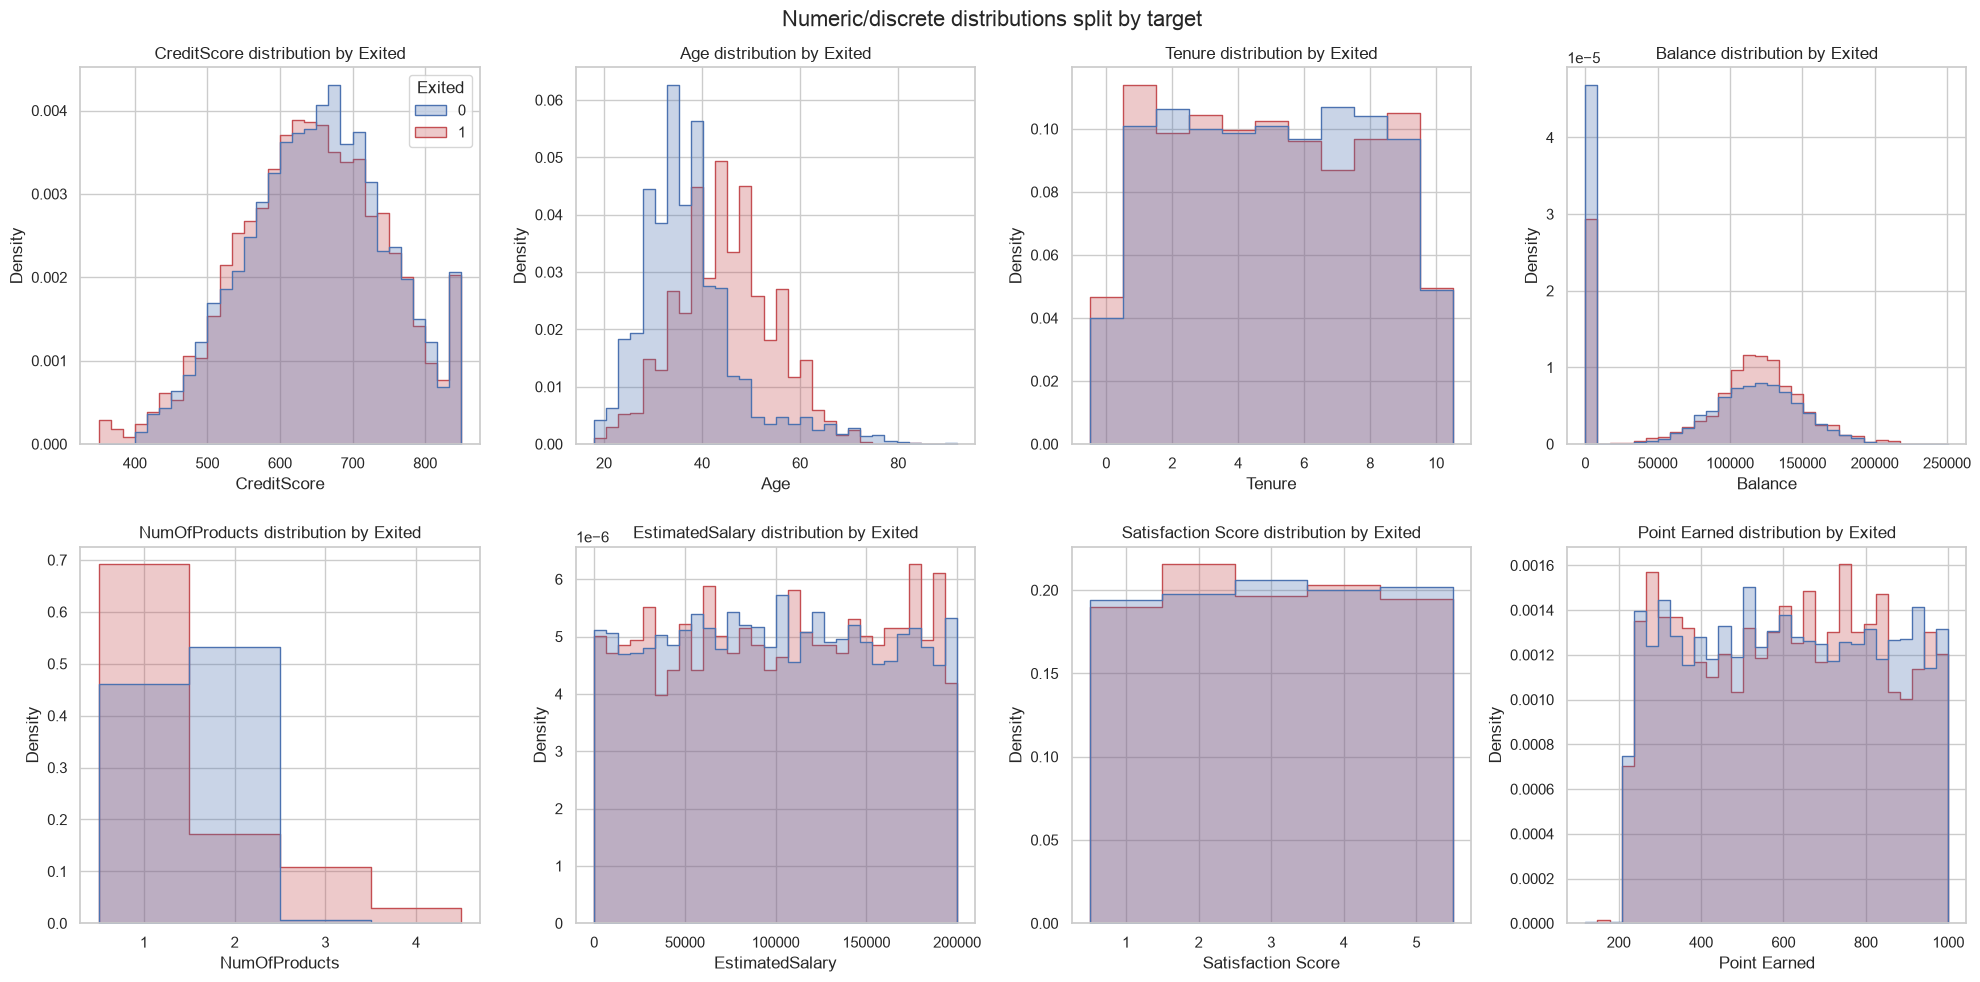

In [8]:
numeric_distribution_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'EstimatedSalary',
    'Satisfaction Score', 'Point Earned',
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for index, (axis, feature) in enumerate(zip(axes.flat, numeric_distribution_features)):
    unique_count = df[feature].nunique()
    bins = (
        np.arange(df[feature].min() - 0.5, df[feature].max() + 1.5, 1)
        if unique_count <= 15 else 30
    )
    sns.histplot(
        data=df,
        x=feature,
        hue=TARGET,
        bins=bins,
        stat='density',
        common_norm=False,
        element='step',
        alpha=0.30,
        palette={0: '#4C72B0', 1: '#C44E52'},
        legend=index == 0,
        ax=axis,
    )
    axis.set_title(f'{feature} distribution by Exited')
    axis.set_ylabel('Density')

fig.suptitle('Numeric/discrete distributions split by target', fontsize=16)
fig.tight_layout()
plt.show()

# 4. Log-transform sensitivity check

Ba cột số không âm được kiểm tra thêm với `log1p`: `Balance`, `EstimatedSalary` và `Point Earned`. Log transform giúp nén thang đo và có thể hữu ích cho linear models hoặc visualization. Với LightGBM, đây là biến đổi đơn điệu nên thường không tạo thêm khả năng phân hạng; raw và log chỉ nên cùng tồn tại nếu ablation chứng minh có lợi.

In [9]:
log_candidate_map = {
    'Balance': 'LogBalance',
    'EstimatedSalary': 'LogEstimatedSalary',
    'Point Earned': 'LogPointEarned',
}
log_candidate_reason = {
    'Balance': 'Large scale with a substantial zero-balance mass',
    'EstimatedSalary': 'Large positive monetary scale',
    'Point Earned': 'Positive accumulated-value scale',
}

log_eda_features = pd.DataFrame(index=df.index)
log_audit_records = []


def quantile_js_divergence(series, target, max_bins=10, smoothing=0.5):
    groups = pd.qcut(series, q=max_bins, duplicates='drop')
    grouped_data = pd.DataFrame({'Group': groups, TARGET: target})
    class_counts = (
        pd.crosstab(grouped_data['Group'], grouped_data[TARGET])
        .reindex(columns=[0, 1], fill_value=0)
        .astype(float)
        + smoothing
    )
    class_0_distribution = class_counts[0] / class_counts[0].sum()
    class_1_distribution = class_counts[1] / class_counts[1].sum()
    midpoint = (class_0_distribution + class_1_distribution) / 2
    return float(0.5 * (
        (class_0_distribution * np.log2(class_0_distribution / midpoint)).sum()
        + (class_1_distribution * np.log2(class_1_distribution / midpoint)).sum()
    ))


for raw_feature, log_feature in log_candidate_map.items():
    assert df[raw_feature].min() >= 0, f'{raw_feature} contains negative values'
    log_eda_features[log_feature] = np.log1p(df[raw_feature])

    raw_js_divergence = quantile_js_divergence(df[raw_feature], df[TARGET])
    log_js_divergence = quantile_js_divergence(
        log_eda_features[log_feature], df[TARGET]
    )
    raw_correlation = abs(df[raw_feature].corr(df[TARGET]))
    log_correlation = abs(log_eda_features[log_feature].corr(df[TARGET]))

    log_audit_records.append({
        'Raw feature': raw_feature,
        'Log feature': log_feature,
        'Reason checked': log_candidate_reason[raw_feature],
        'Zero share': (df[raw_feature] == 0).mean(),
        'Raw skewness': df[raw_feature].skew(),
        'Log skewness': log_eda_features[log_feature].skew(),
        'Raw |correlation|': raw_correlation,
        'Log |correlation|': log_correlation,
        'Correlation change': log_correlation - raw_correlation,
        'Raw JS divergence': raw_js_divergence,
        'Log JS divergence': log_js_divergence,
        'JS change': log_js_divergence - raw_js_divergence,
    })

log_transform_audit = pd.DataFrame(log_audit_records)
log_transform_audit.style.format({
    'Zero share': '{:.2%}',
    'Raw skewness': '{:.4f}',
    'Log skewness': '{:.4f}',
    'Raw |correlation|': '{:.4f}',
    'Log |correlation|': '{:.4f}',
    'Correlation change': '{:+.4f}',
    'Raw JS divergence': '{:.4f}',
    'Log JS divergence': '{:.4f}',
    'JS change': '{:+.4f}',
})

,Raw feature,Log feature,Reason checked,Zero share,Raw skewness,Log skewness,Raw |correlation|,Log |correlation|,Correlation change,Raw JS divergence,Log JS divergence,JS change
0,Balance,LogBalance,Large scale with a substantial zero-balance mass,36.17%,-0.1411,-0.5708,0.1186,0.1228,+0.0042,0.0175,0.0175,+0.0000
1,EstimatedSalary,LogEstimatedSalary,Large positive monetary scale,0.00%,0.0021,-1.9987,0.0125,0.0080,-0.0045,0.0004,0.0004,+0.0000
2,Point Earned,LogPointEarned,Positive accumulated-value scale,0.00%,0.0083,-0.5160,0.0046,0.0047,+0.0001,0.0015,0.0015,+0.0000


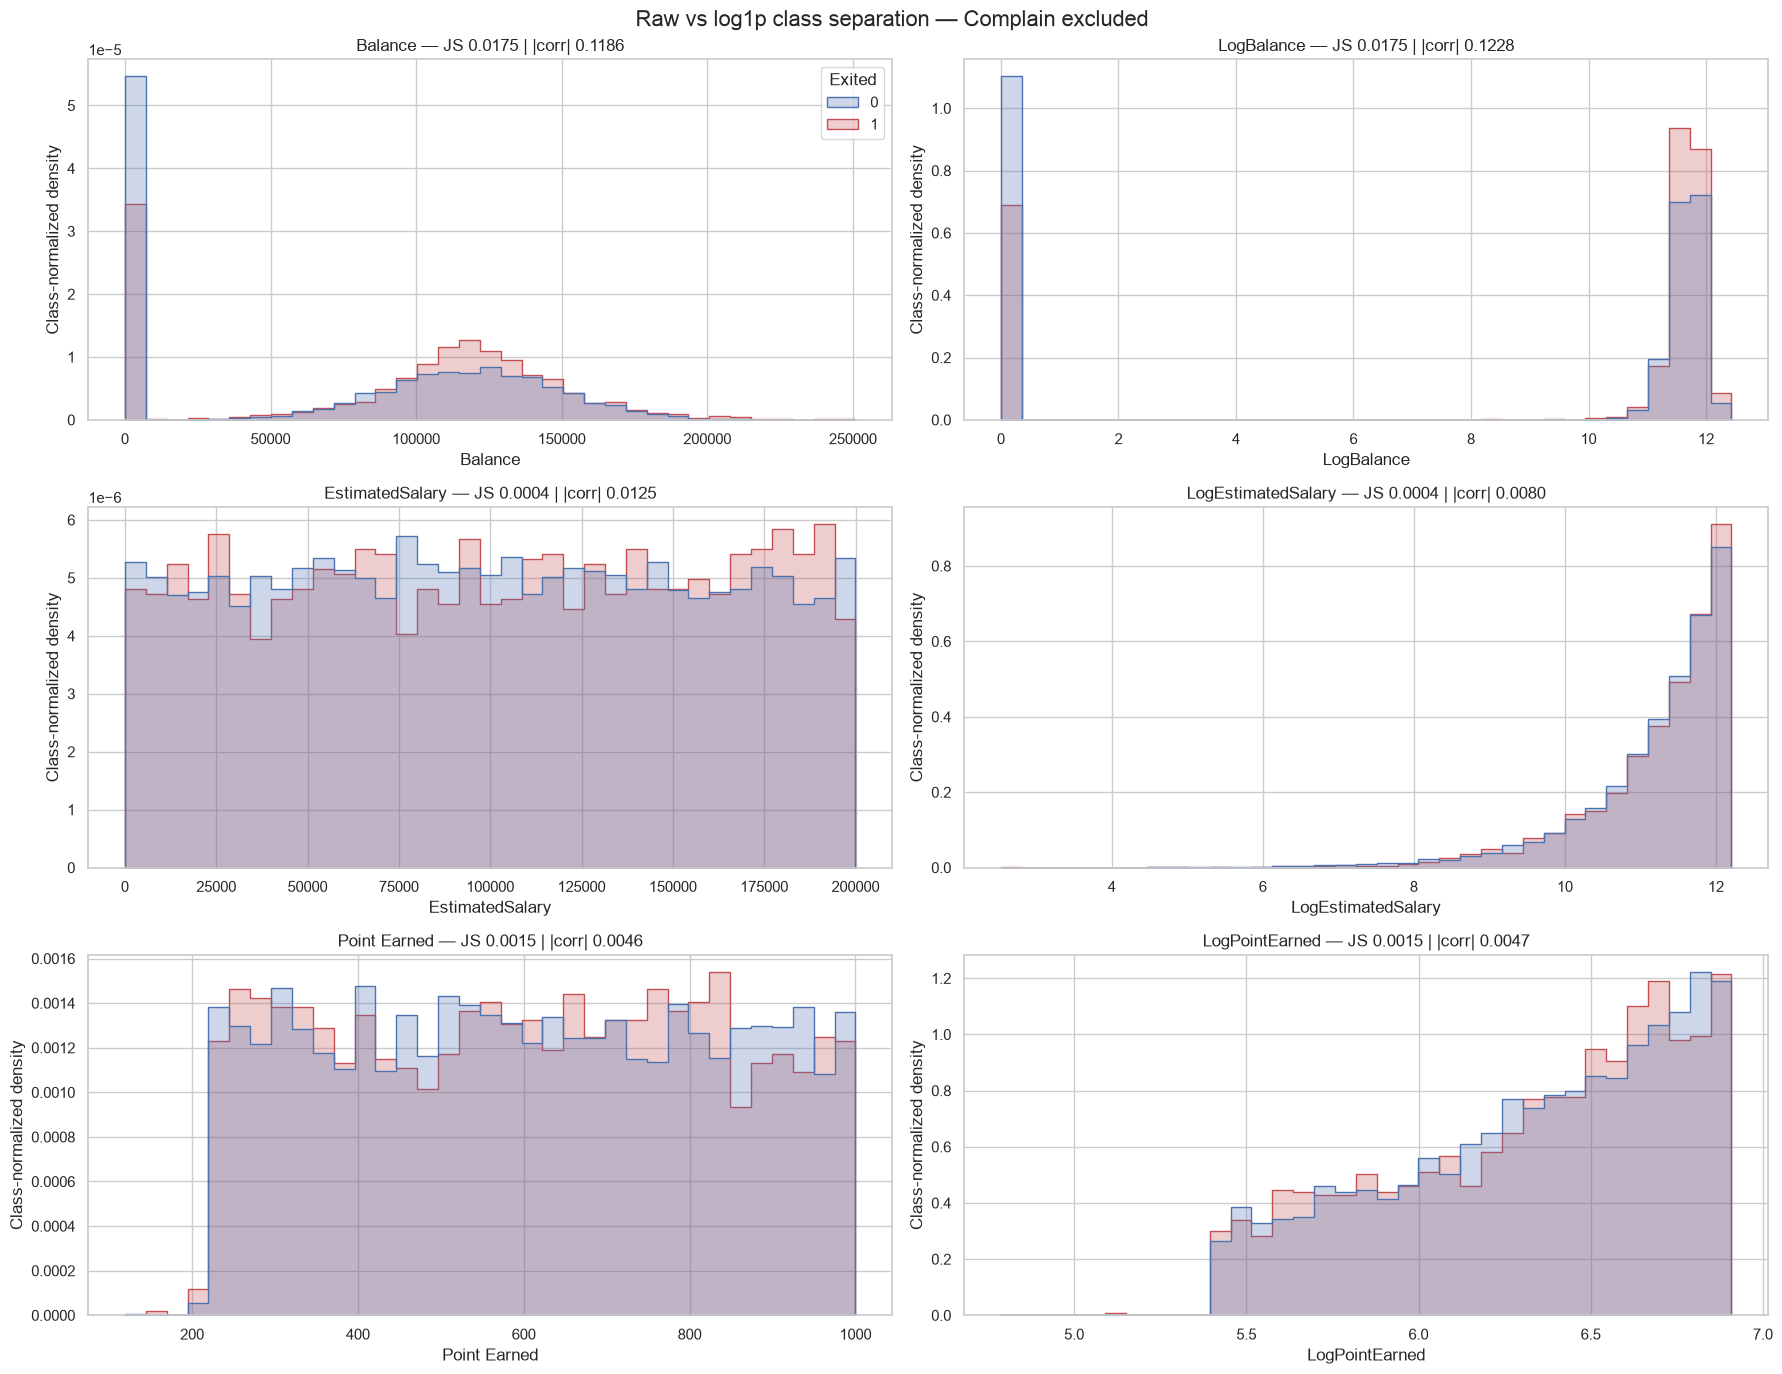

In [10]:
fig, axes = plt.subplots(len(log_candidate_map), 2, figsize=(18, 14))
class_palette = {0: '#4C72B0', 1: '#C44E52'}
audit_lookup = log_transform_audit.set_index('Raw feature')

for row_index, (raw_feature, log_feature) in enumerate(log_candidate_map.items()):
    raw_plot_data = pd.DataFrame({raw_feature: df[raw_feature], TARGET: df[TARGET]})
    log_plot_data = pd.DataFrame({
        log_feature: log_eda_features[log_feature],
        TARGET: df[TARGET],
    })

    sns.histplot(
        data=raw_plot_data,
        x=raw_feature,
        hue=TARGET,
        bins=35,
        stat='density',
        common_norm=False,
        element='step',
        alpha=0.28,
        palette=class_palette,
        legend=row_index == 0,
        ax=axes[row_index, 0],
    )
    sns.histplot(
        data=log_plot_data,
        x=log_feature,
        hue=TARGET,
        bins=35,
        stat='density',
        common_norm=False,
        element='step',
        alpha=0.28,
        palette=class_palette,
        legend=False,
        ax=axes[row_index, 1],
    )

    raw_js = audit_lookup.loc[raw_feature, 'Raw JS divergence']
    log_js = audit_lookup.loc[raw_feature, 'Log JS divergence']
    raw_corr = audit_lookup.loc[raw_feature, 'Raw |correlation|']
    log_corr = audit_lookup.loc[raw_feature, 'Log |correlation|']
    axes[row_index, 0].set_title(
        f'{raw_feature} — JS {raw_js:.4f} | |corr| {raw_corr:.4f}'
    )
    axes[row_index, 1].set_title(
        f'{log_feature} — JS {log_js:.4f} | |corr| {log_corr:.4f}'
    )
    axes[row_index, 0].set_ylabel('Class-normalized density')
    axes[row_index, 1].set_ylabel('Class-normalized density')

fig.suptitle('Raw vs log1p class separation — Complain excluded', fontsize=16)
fig.tight_layout()
plt.show()

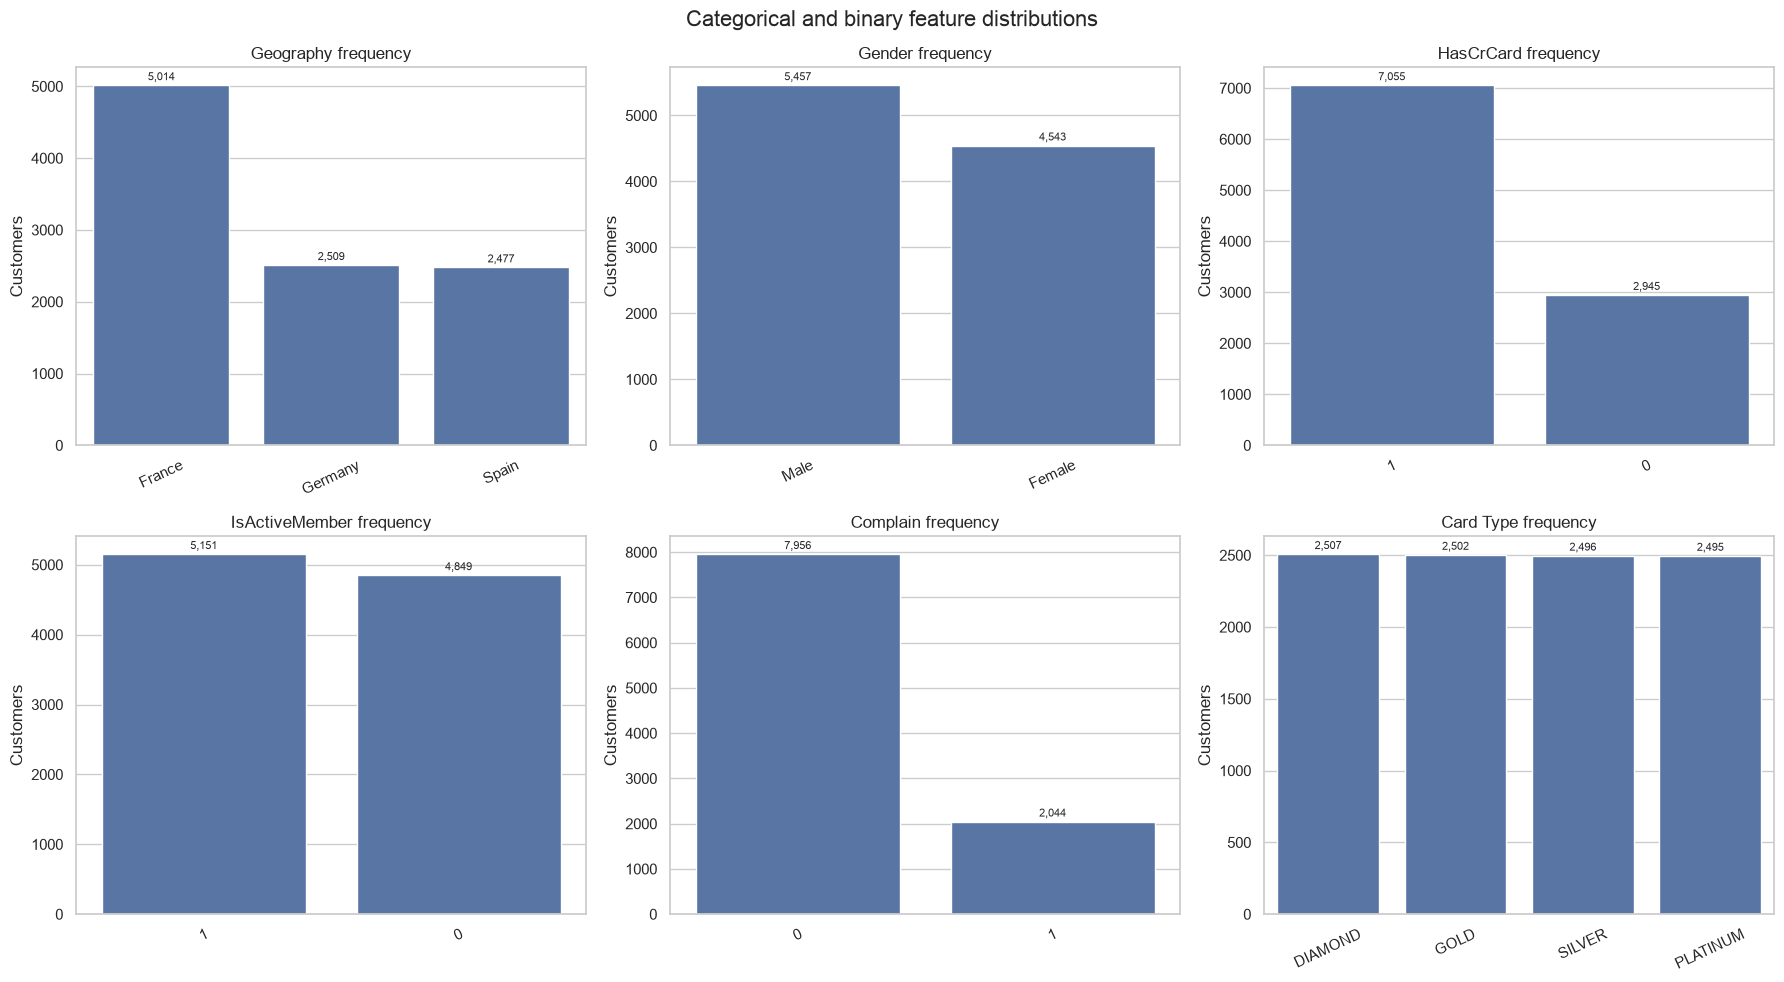

In [11]:
categorical_distribution_features = [
    'Geography', 'Gender', 'HasCrCard',
    'IsActiveMember', 'Complain', 'Card Type',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, feature in zip(axes.flat, categorical_distribution_features):
    order = df[feature].value_counts().index
    sns.countplot(data=df, x=feature, order=order, color='#4C72B0', ax=axis)
    axis.set_title(f'{feature} frequency')
    axis.set_xlabel('')
    axis.set_ylabel('Customers')
    axis.tick_params(axis='x', rotation=25)
    for container in axis.containers:
        axis.bar_label(container, fmt='{:,.0f}', padding=2, fontsize=8)

fig.suptitle('Categorical and binary feature distributions', fontsize=16)
fig.tight_layout()
plt.show()

# 5. Tương quan và độ phân hóa feature–target

Correlation heatmap chỉ áp dụng cho cột số. Sau đó, JS divergence được dùng để xếp hạng thống nhất cả feature số lẫn categorical:

- `0`: phân phối giữa churn và non-churn giống nhau.
- Giá trị càng lớn: khả năng phân hóa đơn biến càng rõ.
- Feature số có hơn 10 giá trị được chia thành 10 quantile, hoàn toàn không dùng target để tạo bin.

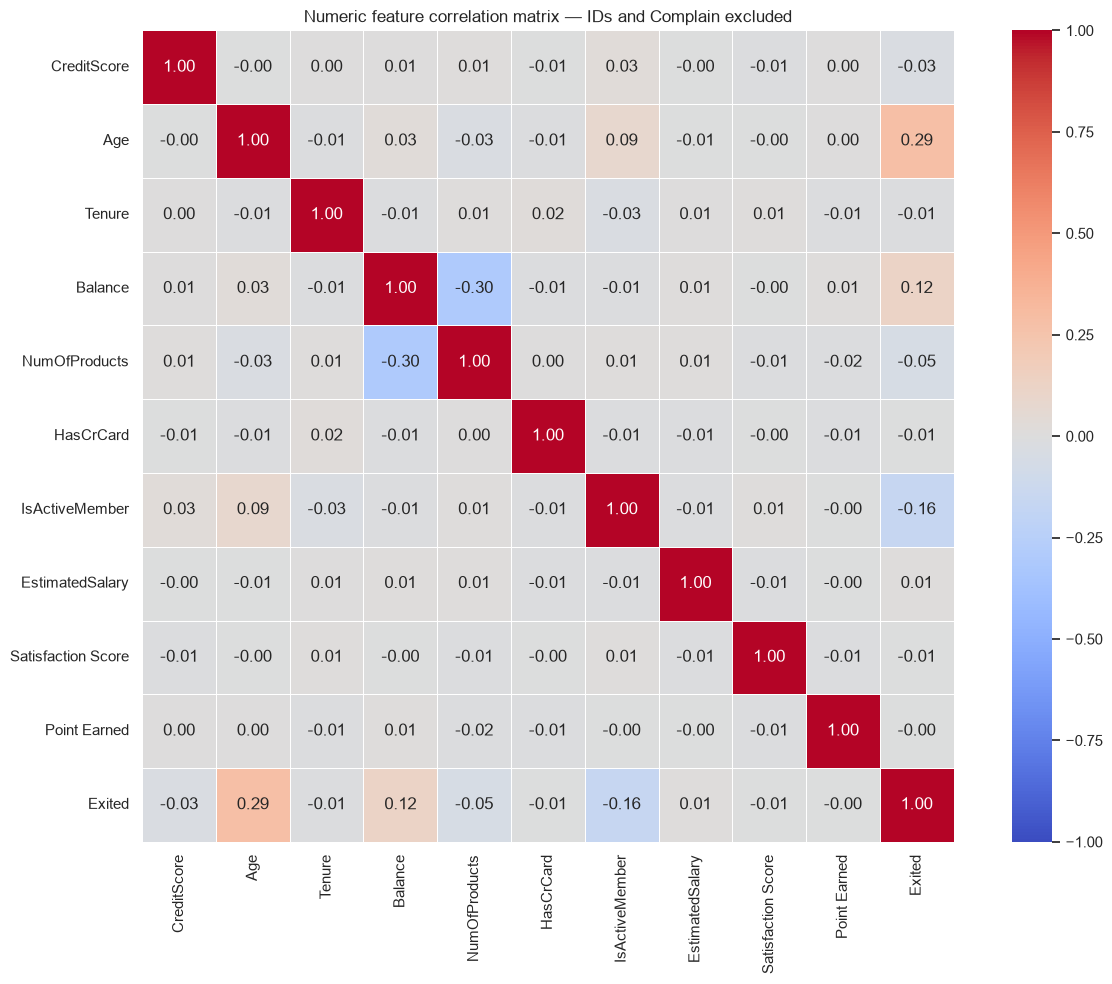

In [12]:
numeric_correlation_columns = [
    column for column in model_feature_columns + [TARGET]
    if pd.api.types.is_numeric_dtype(df[column])
]
correlation_matrix = df[numeric_correlation_columns].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title('Numeric feature correlation matrix — IDs and Complain excluded')
plt.tight_layout()
plt.show()

In [13]:
def build_separation_groups(series, max_bins=10):
    non_missing = series.dropna()
    unique_count = non_missing.nunique()
    is_numeric = pd.api.types.is_numeric_dtype(series)

    if is_numeric and unique_count > max_bins:
        quantile_groups = pd.qcut(series, q=max_bins, duplicates='drop')
        labels = [f'Q{index + 1}' for index in range(len(quantile_groups.cat.categories))]
        quantile_groups = quantile_groups.cat.rename_categories(labels)
        groups = quantile_groups.astype('object').where(series.notna(), 'Missing')
        order = labels + (['Missing'] if series.isna().any() else [])
        return groups.astype(str), order, 'Quantile'

    groups = series.astype('object').where(series.notna(), 'Missing').astype(str)
    if is_numeric:
        order = [str(value) for value in sorted(non_missing.unique())]
    else:
        order = sorted(groups.loc[groups != 'Missing'].unique().tolist())
    if series.isna().any():
        order.append('Missing')
    return groups, order, 'Category/value'


def feature_separation_statistics(series, target, max_bins=10, smoothing=0.5):
    groups, order, grouping = build_separation_groups(series, max_bins=max_bins)
    grouped_data = pd.DataFrame({
        'Group': groups.reset_index(drop=True),
        TARGET: target.reset_index(drop=True),
    })
    class_counts = (
        pd.crosstab(grouped_data['Group'], grouped_data[TARGET])
        .reindex(index=order, fill_value=0)
        .reindex(columns=[0, 1], fill_value=0)
        .astype(float)
        + smoothing
    )
    class_0_distribution = class_counts[0] / class_counts[0].sum()
    class_1_distribution = class_counts[1] / class_counts[1].sum()
    midpoint = (class_0_distribution + class_1_distribution) / 2
    js_divergence = 0.5 * (
        (class_0_distribution * np.log2(class_0_distribution / midpoint)).sum()
        + (class_1_distribution * np.log2(class_1_distribution / midpoint)).sum()
    )
    target_rates = grouped_data.groupby('Group')[TARGET].mean().reindex(order)
    return {
        'JS divergence': float(js_divergence),
        'Target-rate range': float(target_rates.max() - target_rates.min()),
        'Groups used': int(len(order)),
        'Grouping': grouping,
    }


separation_records = []
for feature in feature_columns:
    series = df[feature]
    is_continuous_numeric = (
        pd.api.types.is_numeric_dtype(series)
        and series.nunique(dropna=True) > 10
    )
    separation_records.append({
        'Feature': feature,
        'Type': 'Numeric' if is_continuous_numeric else 'Categorical/discrete',
        'Unique values': int(series.nunique(dropna=True)),
        **feature_separation_statistics(series, df[TARGET]),
        'Leakage risk': 'Review / likely post-event' if feature == 'Complain' else '',
    })

full_feature_separation_table = (
    pd.DataFrame(separation_records)
    .sort_values('JS divergence', ascending=False)
    .reset_index(drop=True)
)
feature_separation_table = (
    full_feature_separation_table.loc[
        full_feature_separation_table['Feature'] != 'Complain'
    ]
    .reset_index(drop=True)
)

feature_separation_table.style.format({
    'JS divergence': '{:.4f}',
    'Target-rate range': '{:.2%}',
}).background_gradient(subset=['JS divergence'], cmap='YlOrRd')

,Feature,Type,Unique values,JS divergence,Target-rate range,Groups used,Grouping,Leakage risk
0,NumOfProducts,Categorical/discrete,4,0.1416,92.40%,4,Category/value,
1,Age,Numeric,70,0.1334,44.31%,10,Quantile,
2,Geography,Categorical/discrete,3,0.0299,16.27%,3,Category/value,
3,IsActiveMember,Categorical/discrete,2,0.0275,12.60%,2,Category/value,
4,Balance,Numeric,6382,0.0175,13.65%,7,Quantile,
5,Gender,Categorical/discrete,2,0.0125,8.60%,2,Category/value,
6,CreditScore,Numeric,460,0.0017,5.13%,10,Quantile,
7,Tenure,Numeric,11,0.0016,5.36%,10,Quantile,
8,Point Earned,Numeric,785,0.0015,4.65%,10,Quantile,
9,Card Type,Categorical/discrete,4,0.0006,2.51%,4,Category/value,


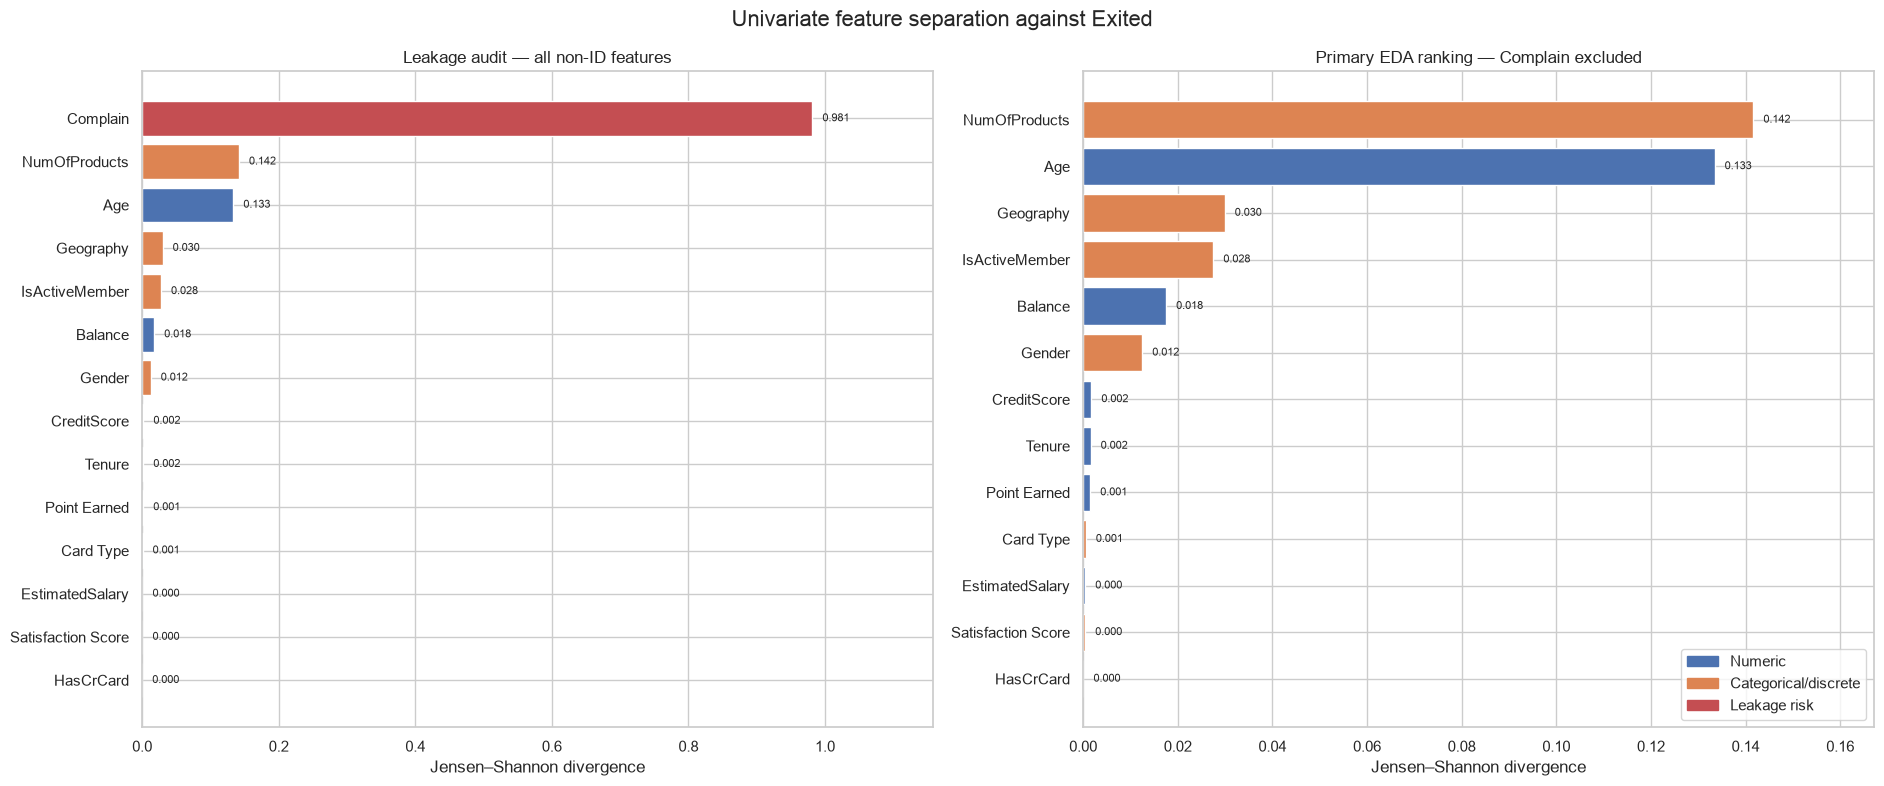

In [14]:
type_colors = {
    'Numeric': '#4C72B0',
    'Categorical/discrete': '#DD8452',
}


def plot_separation_ranking(axis, table, title):
    plot_data = table.sort_values('JS divergence', ascending=True)
    colors = [
        '#C44E52' if feature == 'Complain' else type_colors[feature_type]
        for feature, feature_type in zip(plot_data['Feature'], plot_data['Type'])
    ]
    bars = axis.barh(plot_data['Feature'], plot_data['JS divergence'], color=colors)
    for bar, value in zip(bars, plot_data['JS divergence']):
        axis.text(
            value + plot_data['JS divergence'].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.3f}',
            va='center',
            fontsize=8,
        )
    axis.set_xlim(0, plot_data['JS divergence'].max() * 1.18)
    axis.set_xlabel('Jensen–Shannon divergence')
    axis.set_ylabel('')
    axis.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(19, 8))
plot_separation_ranking(
    axes[0],
    full_feature_separation_table,
    'Leakage audit — all non-ID features',
)
plot_separation_ranking(
    axes[1],
    feature_separation_table,
    'Primary EDA ranking — Complain excluded',
)
axes[1].legend(
    handles=[
        Patch(color='#4C72B0', label='Numeric'),
        Patch(color='#DD8452', label='Categorical/discrete'),
        Patch(color='#C44E52', label='Leakage risk'),
    ],
    loc='lower right',
)
fig.suptitle('Univariate feature separation against Exited', fontsize=16)
fig.tight_layout()
plt.show()

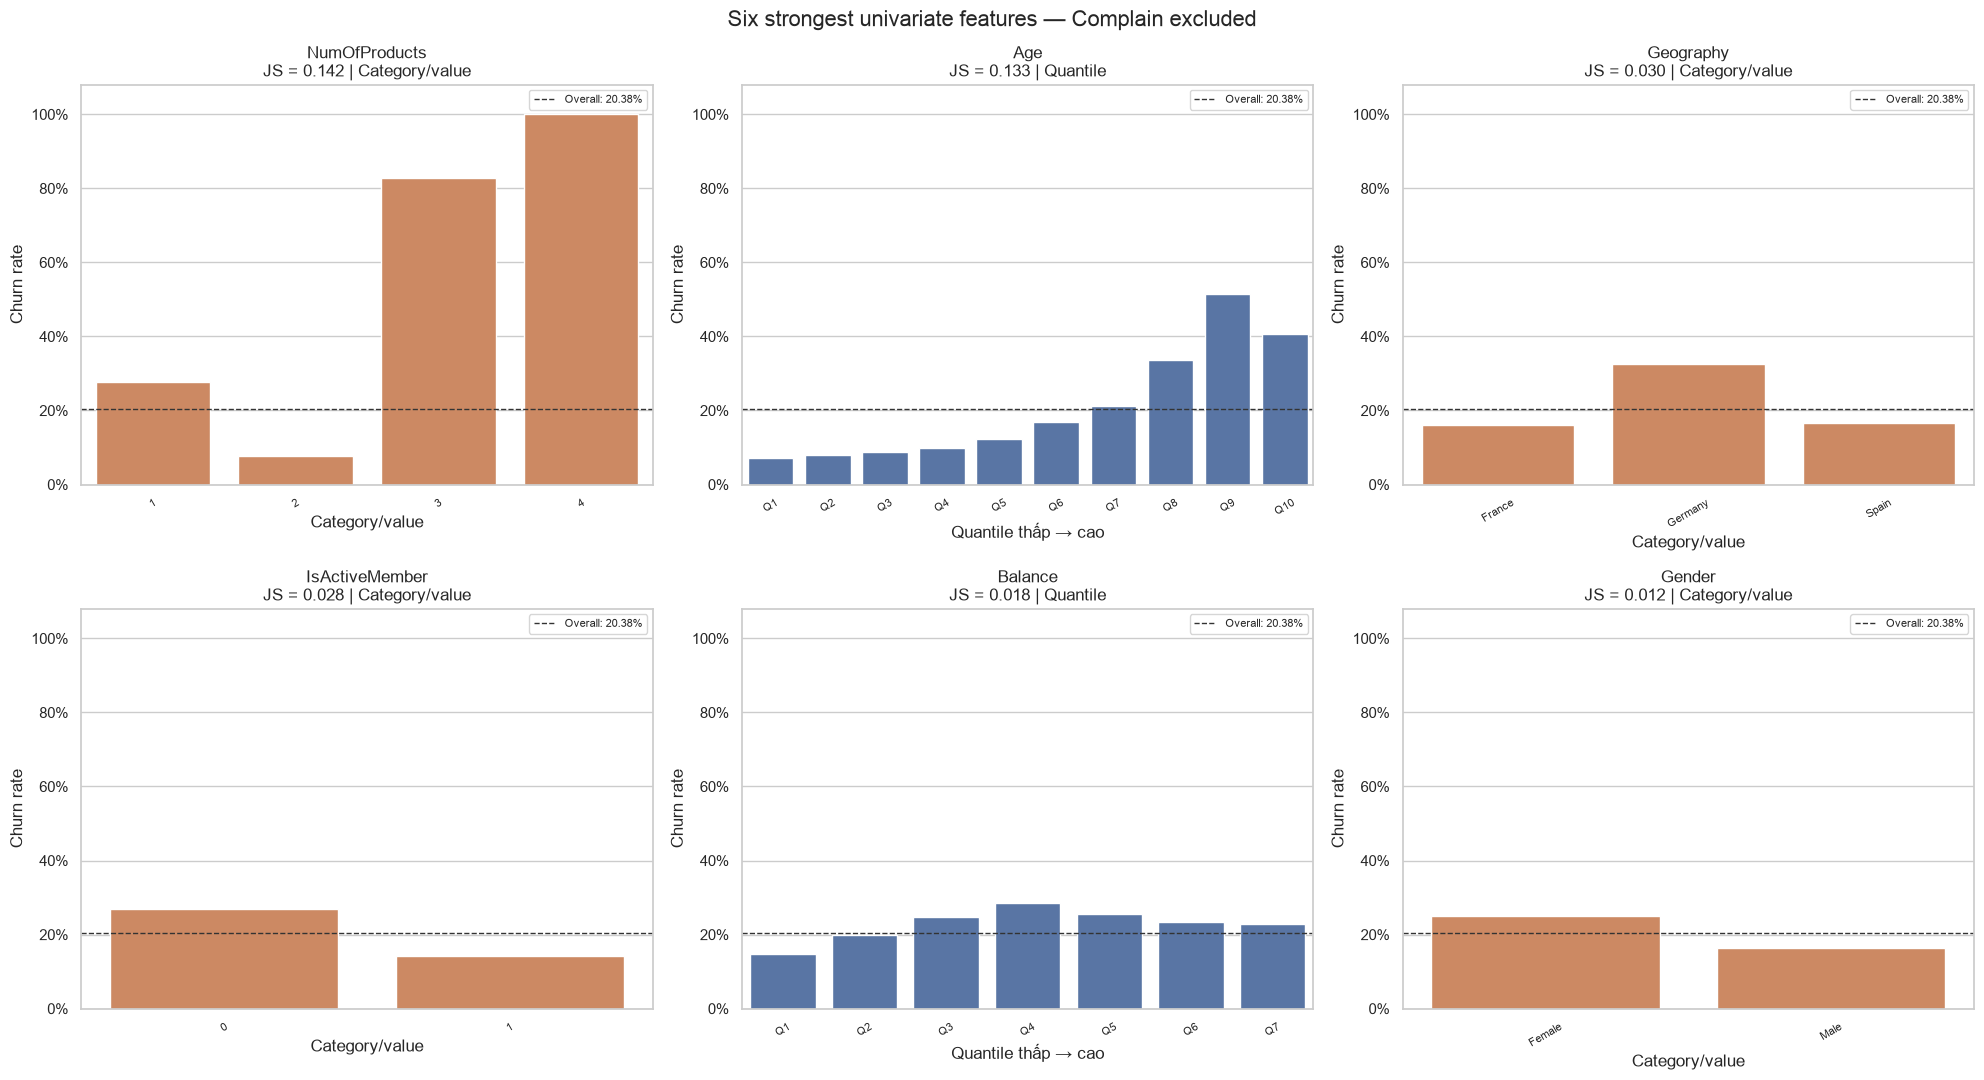

In [15]:
def target_rate_profile(series, target, max_bins=10):
    groups, order, grouping = build_separation_groups(series, max_bins=max_bins)
    profile_data = pd.DataFrame({
        'Group': groups.reset_index(drop=True),
        TARGET: target.reset_index(drop=True),
    })
    profile_data['Group'] = pd.Categorical(
        profile_data['Group'], categories=order, ordered=True
    )
    profile = (
        profile_data.groupby('Group', observed=True)[TARGET]
        .agg(['mean', 'size'])
        .rename(columns={'mean': 'Churn rate', 'size': 'Customers'})
        .reset_index()
    )
    return profile, grouping


top_profile_features = feature_separation_table.head(6)['Feature'].tolist()
feature_lookup = feature_separation_table.set_index('Feature')
overall_churn_rate = df[TARGET].mean()
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

for axis, feature in zip(axes.flat, top_profile_features):
    profile, grouping = target_rate_profile(df[feature], df[TARGET])
    color = '#C44E52' if feature == 'Complain' else type_colors[feature_lookup.loc[feature, 'Type']]
    sns.barplot(data=profile, x='Group', y='Churn rate', color=color, ax=axis)
    axis.axhline(
        overall_churn_rate,
        color='#333333',
        linestyle='--',
        linewidth=1,
        label=f'Overall: {overall_churn_rate:.2%}',
    )
    js_score = feature_lookup.loc[feature, 'JS divergence']
    suffix = ' — REVIEW LEAKAGE' if feature == 'Complain' else ''
    axis.set_title(f'{feature}{suffix}\nJS = {js_score:.3f} | {grouping}')
    axis.set_xlabel('Quantile thấp → cao' if grouping == 'Quantile' else 'Category/value')
    axis.set_ylabel('Churn rate')
    axis.set_ylim(0, 1.08)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))
    axis.tick_params(axis='x', rotation=30, labelsize=8)
    axis.legend(loc='best', fontsize=8)

fig.suptitle('Six strongest univariate features — Complain excluded', fontsize=16)
fig.tight_layout()
plt.show()

In [16]:
top_non_leakage_features = feature_separation_table.head(6)['Feature'].tolist()
complain_rate_0 = complain_churn_rate.loc[0, 'Churn rate']
complain_rate_1 = complain_churn_rate.loc[1, 'Churn rate']
complain_correlation = df[['Complain', TARGET]].corr().loc['Complain', TARGET]

display(Markdown(f'''
# 6. Kết luận EDA

## Data quality

- Dataset có **{len(df):,} dòng × {df.shape[1]} cột**, không có missing value và không có duplicate row.
- Target có **{int(target_counts.get(1, 0)):,} churn ({df[TARGET].mean():.2%})** và **{int(target_counts.get(0, 0)):,} retained ({1 - df[TARGET].mean():.2%})**; cần stratified split và không nên chỉ nhìn accuracy.
- `RowNumber` và `CustomerId` unique 100%; `Surname` có {df['Surname'].nunique():,} giá trị. Cả ba được loại khỏi candidate model features.

## Độ phân hóa và rủi ro leakage

- `Complain` có correlation **{complain_correlation:.4f}** với `Exited`. Churn rate là **{complain_rate_1:.2%}** khi `Complain=1` và chỉ **{complain_rate_0:.2%}** khi `Complain=0`.
- Quan hệ gần như tất định này có thể là dữ liệu được ghi nhận sau/sát thời điểm churn. Cần xác minh thời điểm phát sinh; baseline đáng tin cậy nên **loại `Complain`**, sau đó chạy sensitivity model có cột này để định lượng leakage risk.
- Các feature phân hóa mạnh nhất khi bỏ `Complain`: **{', '.join(top_non_leakage_features)}**.
- `NumOfProducts=3/4` có churn rate rất cao nhưng nhóm nhỏ; cần đọc cùng customer count, không chỉ tỷ lệ.
- Log-transform check có mức thay đổi JS lớn nhất chỉ **{log_transform_audit['JS change'].abs().max():.4f}**; log giúp đổi thang đo nhưng không tạo thêm phân hóa đơn biến theo quantile.

## Chuẩn bị cho modeling

1. Loại `RowNumber`, `CustomerId`, `Surname`; kiểm tra nghiệp vụ trước khi quyết định giữ `Complain`.
2. Stratified split 80/10/10; validation dùng cho tuning/threshold và test chỉ đánh giá sau khi đã đóng băng lựa chọn.
3. One-hot encode `Geography`, `Gender`, `Card Type`; có thể giữ binary/ordinal dưới dạng số.
4. So sánh model **không có `Complain`** với model có `Complain`; report Precision, Recall, F1, ROC-AUC và PR-AUC bên cạnh Accuracy.
'''))


# 6. Kết luận EDA

## Data quality

- Dataset có **10,000 dòng × 18 cột**, không có missing value và không có duplicate row.
- Target có **2,038 churn (20.38%)** và **7,962 retained (79.62%)**; cần stratified split và không nên chỉ nhìn accuracy.
- `RowNumber` và `CustomerId` unique 100%; `Surname` có 2,932 giá trị. Cả ba được loại khỏi candidate model features.

## Độ phân hóa và rủi ro leakage

- `Complain` có correlation **0.9957** với `Exited`. Churn rate là **99.51%** khi `Complain=1` và chỉ **0.05%** khi `Complain=0`.
- Quan hệ gần như tất định này có thể là dữ liệu được ghi nhận sau/sát thời điểm churn. Cần xác minh thời điểm phát sinh; baseline đáng tin cậy nên **loại `Complain`**, sau đó chạy sensitivity model có cột này để định lượng leakage risk.
- Các feature phân hóa mạnh nhất khi bỏ `Complain`: **NumOfProducts, Age, Geography, IsActiveMember, Balance, Gender**.
- `NumOfProducts=3/4` có churn rate rất cao nhưng nhóm nhỏ; cần đọc cùng customer count, không chỉ tỷ lệ.
- Log-transform check có mức thay đổi JS lớn nhất chỉ **0.0000**; log giúp đổi thang đo nhưng không tạo thêm phân hóa đơn biến theo quantile.

## Chuẩn bị cho modeling

1. Loại `RowNumber`, `CustomerId`, `Surname`; kiểm tra nghiệp vụ trước khi quyết định giữ `Complain`.
2. Stratified split 80/10/10; validation dùng cho tuning/threshold và test chỉ đánh giá sau khi đã đóng băng lựa chọn.
3. One-hot encode `Geography`, `Gender`, `Card Type`; có thể giữ binary/ordinal dưới dạng số.
4. So sánh model **không có `Complain`** với model có `Complain`; report Precision, Recall, F1, ROC-AUC và PR-AUC bên cạnh Accuracy.
